## 2. (Optional) Automatic Mask Placement

Automatic Mask Placement allows you to intelligently place and augment defect masks within specific regions of interest (ROIs), addressing limitations of traditional image-wide augmentation.

If you have already prepared the masks for generation, you can skip this step.

For detailed user guide with usecases, please reference tutorial/Auto Mask-Placement (AMP) GUI Tutorial.md.

### 2.0 Setting Up the Environment

This notebook requires the user to set the environment variable `LOCAL_PROJECT_DIR` to the path of the PAIDF AnomalyGen repo. Remember to replace `FIXME` placeholder below with the correct path.

In [ ]:
# Set `LOCAL_PROJECT_DIR` for PAIDF AnomalyGen.
LOCAL_PROJECT_DIR="FIXME"
# Set the working directory to this path for the shell.
%cd {LOCAL_PROJECT_DIR}
# Use `cd ${LOCAL_PROJECT_DIR}` if you are copy-pasting this into a terminal.

### 2.1 Motivation

Traditional augmentation applies transformations to entire mask images uniformly, which cannot handle scenarios like:
- **Defects occurring only on specific objects** (e.g., scratches on certain components)
- **Restricted ROIs** (e.g., contamination in specific areas only)
- **Alignment requirements** (e.g., cracks following seam edges)

Automatic Mask Placement solves these by allowing you to define legal/illegal regions and alignment constraints.

### 2.2 GUI Interface

The Automatic Mask Placement GUI is the **primary and recommended interface** for most users.
It provides visualization and interactive control, making it the most efficient way
to design, debug, and validate mask placement strategies.

The CLI interface is intended for batch processing and fully reproducible large-scale generation
after configurations have been verified through the GUI.

To start the GUI server:

```bash
conda run -n cosmos-predict2 bash -c 'AMP_PORT=5000 python3 -m amp_gui.backend.app'
```

`AMP_PORT` specifies the port number on which the GUI backend server listens.
If not explicitly set, the backend will use its default port 5000.

After starting the server, open a web browser and navigate to:
```
http://localhost:<AMP_PORT>
```


### 2.3 Parameters Reference

Available arguments for the automatic mask placement script:

#### Required Parameters

- `--submask` **(required)**: Path to the binary submask image to be placed.
- `--output_base_dir` **(required)**: Base output directory (subdirectories created for each seed).

**ROI Definition (at least one required):**
- `--rois`: JSON file containing ROI definitions.
- `--roi_image`: Binary image(s) defining legal regions (white = legal).

**Instance Count (at least one required):**
- `--n`: Number of instances to generate (fixed for all seeds).
- `--n_range MIN MAX`: Random N range - each seed gets a random N value in [MIN, MAX].

**Seed Control (mutually exclusive, one required):**
- `--seed`: Single seed value (use `"None"` for random behavior, enables real-time output). Default: random.
- `--seed_range START END`: Seed range for batch generation (e.g., `1 20` generates seeds 1-20).
- `--seed_list "S1,S2,..."`: Specific seed list (e.g., `"1,5,10,42"`).

#### Optional Parameters

**Illegal ROI (optional):**
- `--illegal_roi_image`: Binary image(s) defining forbidden regions (white = illegal).

**Alignment Options (optional):**
- `--roi_alignment_point`: Where to align mask within ROI. Options: `center`, `top_left`, `top_right`, `bottom_left`, `bottom_right`, `top_center`, `bottom_center`, `left_center`, `right_center`, `random`. Default: `center`.
- `--submask_alignment_point`: Fixed point for submask augmentation (same options as above). Default: `None` (no fixed alignment).
- `--strict_alignment`: Disable shifting to prevent boundary clipping (intelligently allows safe flips based on alignment point). Default: `False`.

**Output Control (optional):**
- `--save_visualize`: Save ROI visualization overlay.
- `--save_roi_binaries`: Save binary images of processed ROIs.
- `--save_separated_rois`: Save individual ROI masks.
- `--save_cropped_submask`: Save the cropped submask before augmentation.
- `--save_augmented_masks`: Save intermediate augmented masks.

**Batch Processing (optional):**
- `--parallel_workers`: Number of parallel processes for batch generation. Default: `1` (sequential).
- `--output_naming`: Output organization strategy. Options: `seed_subdir` (creates subdirectories) or `seed_suffix` (adds seed to filenames). Default: `seed_subdir`.

**Other Options (optional):**
- `--aug_config`: Path to custom augmentation configuration JSON file.
- `--min_area`: Minimum ROI area threshold for filtering small regions. Default: `10`.

#### 2.3.1 (Optional) Augmentation Configuration

By default, you **don't need** to configure augmentation parameters. The tool provides **dynamic defaults** that intelligently determine reasonable augmentation ranges based on your submask and ROI characteristics.

However, if you need fine-grained control, you can provide a custom configuration file using `--aug_config`.

#### Key Augmentation Parameters

| Parameter | Default Behavior | Description |
|-----------|------------------|-------------|
| `shift_x_range` / `shift_y_range` | Dynamic (auto-calculated) | Pixel shift range for mask translation |
| `rotation_range` | Dynamic (auto-calculated) | Rotation angle range in degrees |
| `shear_range` | Dynamic (auto-calculated) | Shear transformation range in degrees |
| `scale_range` | `[0.8, 1.2]` | Scale factor range for mask resizing |
| `flip_x_probability` | `0.5` | Probability of horizontal flip |
| `flip_y_probability` | `0.5` | Probability of vertical flip |
| `shift_x_probability` | `1.0` | Probability of applying shift in X direction |
| `shift_y_probability` | `1.0` | Probability of applying shift in Y direction |
| `rotation_probability` | `1.0` | Probability of applying rotation |
| `shear_x_probability` | `1.0` | Probability of applying shear in X direction |
| `shear_y_probability` | `1.0` | Probability of applying shear  in Y direction |
| `scale_x_probability` | `1.0` | Probability of applying scaling in X direction |
| `scale_y_probability` | `1.0` | Probability of applying scaling  in Y direction |
| `morph_operations` | `['dilate', 'erode', 'open', 'close']` | Morphological operations to apply |
| `morph_kernel_size` | `3` | Kernel size for morphological operations |
| `morph_probability` | `1.0` | Probability of applying morphological ops |

**How Dynamic Defaults Work:**
- Analyzes submask dimensions and ROI sizes to calculate safe transformation ranges
- Automatically limits transformations to keep augmented masks within ROI boundaries
- No manual tuning required for most use cases

**Example Custom Configuration** (`augmentation_config.json`):
```json
{
  "shift_x_range": [-20, 20],
  "shift_y_range": [-20, 20],
  "rotation_range": [-30, 30],
  "scale_range": [0.7, 1.3],
  "shear_range": [-10, 10],
  "flip_x_probability": 0.3,
  "flip_y_probability": 0.3,
  "morph_kernel_size": 5
}
```

**Usage:**
```bash
python3 -m scripts.anomaly_gen.automatic_mask_placement \
    --submask path/to/submask.png \
    --roi_image path/to/roi.png \
    --n 5 \
    --output_base_dir results/ \
    --aug_config augmentation_config.json  # Use custom config
```

**Tip**: Start without `--aug_config` and only use it if you need specific augmentation behavior.

### 2.4 ROI Generation

ROI Generation provides an automated workflow for producing masks that define legal and illegal regions for **Automatic Mask Placement**.
It integrates SAM2-based segmentation to minimize manual annotation effort, supporting three methods:

| Method                    | Prompt Required | Description                                                                                                   | Recommend Usecase    |
|---------------------------|-----------------|---------------------------------------------------------------------------------------------------------------|----------------------|
| **Grayscale-to-Mask**     | None            | Converts grayscale intensity into a binary mask.                                                              | Bright or dark areas |
| **Box-to-Mask**           | At least 1 box  | Converts user-provided bounding boxes into segmentation masks.                                                | Specific objects     |
| **Template-Box-to-Masks** | At least 1 box  | Finds instances with similar shape and appearance across the image compare to instance in the template boxes. | Similar objects      |

#### 2.4.1 Parameters Reference

Available arguments for the ROI Generation script:

##### Required Parameters

- `--input_samples`: Path to a JSON file describing one or more samples. 
    Each sample must include:

    - `image_path`: Path to the input image file.

    - `boxes`: A list of user-provided bounding boxes.
            Each box is defined as [x0, y0, x1, y1]

    - `config` (optional; overrides defaults): Detailed configuration options are explained in [Section 2.4.2](#242-detailed-configuration).

    Example:
    ```bash
    --input_samples samples/roi_examples.json
    ```

    Sample JSON structure:
    ```json
    [
        {
            "image_path": "path/to/image1.png",
            "boxes": [[87,23,114,50]],
        },
        {
            "image_path": "path/to/image2.png",
            "boxes": [[87,23,114,50]],
            "config": {
                "template_box_to_masks": {
                    "filters": {
                        "color_hist": { "enabled": false }
                    }
                }
            }
        }
    ]
    ```

##### Optional Parameters

- `--output`: Output directory for saving generated ROI masks, visualizations, and logs.
    
    Default: `./results/roi_generate`

    Example:
    ```bash
    --output results/automatic_mask_placement/roi_generate
    ```

    The generated binary mask will be saved under: `<output>/sample_<index>/<method>/output/binary_mask.png`.

    Multiple methods can run in one command, and results are stored in separate folders:

    ```lua
    <output>/
    ├── grayscale_to_mask/
    ├── box_to_mask/
    └── template_box_to_masks/
    ```

#### 2.4.2 Detailed Configuration

**Basic Setting:**
| Field                                  | Datatype | Default  | Description                                                                                                                                                                                        | Supported Values                                   |
| -------------------------------------- | -------- | -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------- |
| **grayscale_to_mask.enabled**          | bool     | `true`   | Enables Grayscale-to-Mask method.                                                                                                                                                                  | `true`, `false`                                    |
| **grayscale_to_mask.threshold_mode**   | string   | `"otsu"` | Thresholding mode for binarization.                                                                                                                                                                | `"otsu"`, `"otsu_inv"`, `"custom"`, `"custom_inv"` |
| **grayscale_to_mask.threshold_value**  | int      | `128`    | Threshold used **only when** `grayscale_to_mask.threshold_mode` is set to `"custom"` or `"custom_inv"`. </br> Pixels are compared against this grayscale value to determine foreground/background. | `0–255`                                            |
| **box_to_mask.enabled**                | bool     | `true`   | Enables Box-to-Mask method.                                                                                                                                                                        | `true`, `false`                                    |
| **template_box_to_masks.enabled**      | bool     | `true`   | Enables Template-Box-to-Masks method.                                                                                                                                                              | `true`, `false`                                    |
| **template_box_to_masks.max_proposal** | int      | `300`    | Maximum number of proposals to generate.                                                                                                                                                           | Positive integer                                   |
    

<details>
<summary>**Advanced Settings (Click to show)**</summary>

**Settings Shared for Three Methods:**
| Field                       | Datatype       | Default  | Description                                                                                                                | Supported Values                                   |
| --------------------------- | -------------- | -------- | -------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------- |
| **save_visualization**      | bool           | `false`  | Whether to save visualization outputs such as overlay masks or debugging figures under `<output>/<method>/visualization/`. | `true`, `false`                                    |
| **morphological_operation** | string / null  | `null`   | Morphological operation used to refine binary masks.                                                                       | `null`, `"dilate"`, `"erode"`, `"close"`, `"open"` |
| **morphological_kernel**    | list[int, int] | `[3, 3]` | Kernel size for morphological refinement.                                                                                  | 2-element list of positive integers                |

**Resize Setting:**
| Field                                  | Datatype | Default | Description                                                                                                                                                                                | Supported Values |
| -------------------------------------- | -------- | ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------- |
| **box_to_mask.image_resize**           | int      | `1024`  | Optional pre-resize applied **only when the image’s larger dimension exceeds this value**. <br> The image is downscaled so that its longest side equals `image_resize` before segmentation | Positive integer |
| **template_box_to_masks.image_resize** | int      | `1024`  | Optional pre-resize applied **only when the image’s larger dimension exceeds this value**. <br> The image is downscaled so that its longest side equals `image_resize` before segmentation | Positive integer |
|                                        |          |         |                                                                                                                                                                                            |                  |

**Cache Settings:**
| Field                                  | Datatype | Default | Description                                         | Supported Values |
| -------------------------------------- | -------- | ------- | --------------------------------------------------- | ---------------- |
| **template_box_to_masks.save_cache**   | bool     | `true`  | Save cached intermediate results.                   | `true`, `false`  |
| **template_box_to_masks.resume_cache** | bool     | `true`  | Reuse cached intermediate results for faster rerun. | `true`, `false`  |


**Template Augmentation Settings:**
| Field                                      | Datatype  | Default | Description                                                  | Supported Values                                    |
| ------------------------------------------ | --------- | ------- | ------------------------------------------------------------ | --------------------------------------------------- |
| **template_box_to_masks.refine_template**  | bool      | `true`  | Whether to refine template boxex prior to template matching. | `true`, `false`                                     |
| **template_box_to_masks.max_template**     | int       | `3`     | Maximum number of template boxes used for matching.          | Positive integer                                    |
| **template_box_to_masks.crop_resize**      | int       | `224`   | Resize resolution applied to template crops.                 | Positive integer                                    |
| **template_box_to_masks.rotation_degrees** | list[int] | `[0]`   | Allowed rotation degrees for augmented templates.            | List of positive integers e.g., `[0, 90, 180, 270]` |
| **template_box_to_masks.allow_flip**       | list[str] | `[]`    | Flipping augmentation for templates.                         | `"horizontal"`, `"vertical"`                        |


**Filtering Settings:**
| Field                                             | Datatype | Default | Description                                                                         | Supported Values     |
| ------------------------------------------------- | -------- | ------- | ----------------------------------------------------------------------------------- | -------------------- |
| **template_box_to_masks.proposal_similarity_tol** | float    | `0.5`   | Maximum allowed difference in feature similarity for proposal candidates.           | `0.0 – 1.0`          |
| **template_box_to_masks.box_enabled**             | bool     | `true`  | Whether to enable bounding-box–level filtering.                                     | `true`, `false`      |
| **template_box_to_masks.size_tol**                | float    | `0.3`   | Maximum allowed relative diagonal size difference between proposal and template.    | `0.0 – 1.0`          |
| **template_box_to_masks.aspect_tol**              | float    | `0.3`   | Maximum allowed relative aspect-ratio difference between proposal and template.     | `0.0 – 1.0`          |
| **template_box_to_masks.mask_enabled**            | bool     | `true`  | Whether to enable mask-shape–level filtering.                                       | `true`, `false`      |
| **template_box_to_masks.component_count_tol**     | int      | `0`     | Maximum allowed difference in connected-component count (`0` = identical).          | Non-negative integer |
| **template_box_to_masks.chamfer_tol**             | float    | `0.025` | Maximum allowed normalized Chamfer distance between masks of proposal and tempalte. | `0.0 – 1.0`          |
| **template_box_to_masks.hog_enabled**             | bool     | `true`  | Whether to enable HOG-based texture filtering.                                      | `true`, `false`      |
| **template_box_to_masks.hog_similarity_tol**      | float    | `0.8`   | Maximum allowed difference in HOG feature similarity between proposal and template. | `0.0 – 1.0`          |
| **template_box_to_masks.color_hist_enabled**      | bool     | `true`  | Whether to enable color-histogram filtering.                                        | `true`, `false`      |
| **template_box_to_masks.color_tol**               | float    | `0.7`   | Maximum allowed color histogram difference between proposal and template.           | `0.0 – 1.0`          |
| **template_box_to_masks.lightness_tol**           | float    | `0.7`   | Maximum allowed lightness histogram difference between proposal and template.       | `0.0 – 1.0`          |

**Runtime & Cache Note**

- **template_box_to_masks.max_template** and **template_box_to_masks.max_proposal** have the largest impact on runtime.
More templates or proposals require more feature extraction and filtering.

- With **template_box_to_masks.save_cache = true**, all major intermediate results are stored to `<output>/sample_<index>/template_box_to_masks/cache/` for later reuse.

- With **template_box_to_masks.resume_cache = true**, cached results are loaded if the output path keep unchanged.
Only stages affected by changes in core or advanced filtering settings will run again.

- Changing **only filtering parameters** reuses the entire cache, enabling very fast re-runs.

- **save_visualization** is time-comsuming and only runs for stages that are re-executed. Cached stages skip visualization.

- For large or repeated runs, it is recommended to disable **save_visualization**.
</details>


### 2.5 Example 1: Reversi Board Inspection

**Scenario:** Masks should appear **around black chess pieces** but **avoid all chess pieces**.

This example demonstrates how [**ROI Generation**](#23-roi-generation) integrates with **Automatic Mask Placement**.

#### 2.5.1 Step 1: Prepare Inputs

Let's visualize the inputs we'll use:

INPUTS FOR THIS EXAMPLE:
[Input 1] Submask:      assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/submask/reversi_sample_submask.png
[Input 2] Legal ROI:    assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/rois/json/reversi_sample_rois.json (JSON file)

Legal ROI JSON content:
{
  "rois": [
    {
      "id": "main_mask_01",
      "x": 22,
      "y": 145,
      "width": 33,
      "height": 46,
      "is_legal": true
    },
    {
      "id": "main_mask_02",
      "x": 145,
      "y": 144,
      "width": 31,
      "height": 46,
      "is_legal": true
    },
    {
      "id": "main_mask_03",
      "x": 218,
      "y": 146,
      "width": 31,
      "height": 46,
      "is_legal": true
    }
  ]
}

Note: Legal ROI JSON is converted to a binary image for visualization only.
The actual input used by the tool is the JSON file.



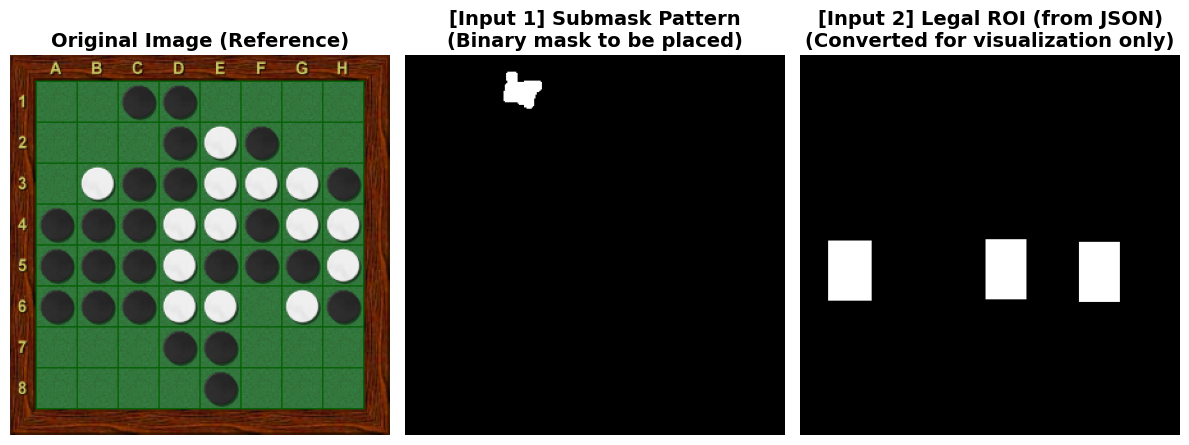

All inputs visualized successfully!


In [2]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os
import json
import numpy as np

# Define paths (these are the ACTUAL inputs we'll use)
reversi_dir = 'assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example'
original_img_path = os.path.join(reversi_dir, 'image/reversi.png')
submask_path = os.path.join(reversi_dir, 'submask/reversi_sample_submask.png')
rois_json_path = os.path.join(reversi_dir, 'rois/json/reversi_sample_rois.json')

print("=" * 60)
print("INPUTS FOR THIS EXAMPLE:")
print("=" * 60)
print(f"[Input 1] Submask:      {submask_path}")
print(f"[Input 2] Legal ROI:    {rois_json_path} (JSON file)")
print("=" * 60 + "\n")

# Load actual input files
img_original = Image.open(original_img_path)
img_submask = Image.open(submask_path)

# Read and display JSON content
with open(rois_json_path, 'r') as f:
    rois_data = json.load(f)

print("Legal ROI JSON content:")
print(json.dumps(rois_data, indent=2))
print()

# Convert JSON ROI to image for visualization ONLY
# This is NOT an input file, just for visualization purposes
img_size = img_original.size
legal_roi_vis = Image.new('L', img_size, 0)  # Black background
draw = ImageDraw.Draw(legal_roi_vis)

for roi in rois_data['rois']:
    if roi.get('is_legal', True):
        x = roi['x']
        y = roi['y']
        w = roi['width']
        h = roi['height']
        # Draw white rectangle for this ROI
        draw.rectangle([x, y, x+w, y+h], fill=255)

print("Note: Legal ROI JSON is converted to a binary image for visualization only.")
print("The actual input used by the tool is the JSON file.\n")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 10))

axes[0].imshow(img_original)
axes[0].set_title('Original Image (Reference)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_submask, cmap='gray')
axes[1].set_title('[Input 1] Submask Pattern\n(Binary mask to be placed)', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(legal_roi_vis, cmap='gray')
axes[2].set_title('[Input 2] Legal ROI (from JSON)\n(Converted for visualization only)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("All inputs visualized successfully!")


To **exclude all chess pieces**, **Automatic Mask Placement** requires an illegal ROI mask that covers every chess piece in the image.

Expected illegal ROI mask:

![ROI Mask](../../assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/rois/image/illegal/reversi_sample_illegal_region.png)

Since all chess pieces have **similar shape, color, and structure**, this task is well suited for the **Template-Box-to-Masks** method of **ROI Generation**, which can automatically detect and segment all visually similar pieces based on a single provided bounding box.

The following steps illustrate how to create this mask.

##### 2.5.1.1 Prepare Input JSON for ROI Generation
Start by drawing a bounding box around one black chess piece.

Then create a `samples.json` file that specifies:

- the image path

- the bounding box for the template instance

A reference example JSON file is provided at: `ag_inference/reversi/roi_generate_example.json`

In [ ]:
import json

boxes = [[87,23,114,50], [54,86,82,113]]

sample_json = [
    {
        "image_path": "assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/reversi.png",
        "boxes": boxes,
    }
]

with open("assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/samples.json", "w") as f:
    json.dump(sample_json, f, indent=4)

Visualization of the box:

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

original_img_path = 'assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/reversi.png'

# Load image
img_original = Image.open(original_img_path)

# Draw bounding boxes
img_with_box = img_original.copy()
draw = ImageDraw.Draw(img_with_box)
for x0, y0, x1, y1 in boxes:
    draw.rectangle([x0, y0, x1, y1], outline="blue", width=2)

# Visualize single image
plt.figure(figsize=(8, 6))
plt.imshow(img_with_box)
plt.title("[Input] User-Provided Bounding Box", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()


##### 2.5.1.2 Run ROI Generate

In [ ]:
!conda run -n cosmos-predict2 \
   bash -c "python -m scripts.anomaly_gen.roi_generate \
    --output results/automatic_mask_placement/roi_generate \
    --input_samples assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/samples.json"

Visulization of ROI Generation result:

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np

original_img_path = 'assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/reversi.png'
roi_paths = [
    'results/automatic_mask_placement/roi_generate/sample_00001/grayscale_to_mask/output/binary_mask.png',
    'results/automatic_mask_placement/roi_generate/sample_00001/box_to_mask/output/binary_mask.png',
    'results/automatic_mask_placement/roi_generate/sample_00001/template_box_to_masks/output/binary_mask.png',
]

def overlay_mask(img, mask, color=(0,0,255), alpha=0.5):
    img_np = np.array(img).astype(np.float32)
    m = np.array(mask)
    img_np[m > 0] = (1-alpha)*img_np[m>0] + alpha*np.array(color)
    return Image.fromarray(img_np.astype(np.uint8))

img_original = Image.open(original_img_path).convert("RGB")
roi_imgs = [Image.open(p).convert("L") for p in roi_paths]

overlays = []
for i in range(3):
    roi = roi_imgs[i]
    ov = overlay_mask(img_original, roi)
    if i != 0 :
        draw = ImageDraw.Draw(ov)
        for x0, y0, x1, y1 in boxes:
            draw.rectangle([x0, y0, x1, y1], outline="blue", width=3)
    overlays.append(ov)

titles_mask = ["Grayscale-to-Mask", "Box-to-Mask", "Template-Box-to-Masks"]
titles_overlay = ["Overlay", "Overlay", "Overlay"]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
for i in range(3):
    axes[i][0].imshow(roi_imgs[i], cmap="gray")
    axes[i][0].set_title(titles_mask[i])
    axes[i][0].axis("off")

    axes[i][1].imshow(overlays[i])
    axes[i][1].set_title(titles_overlay[i])
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()


This mask at `results/automatic_mask_placement/roi_generate/sample_00001/template_box_to_masks/output/binary_mask.png` can then be used as the input to Automatic Mask Placement, ensuring that defects are generated around the chess pieces but **never on** them.

#### 2.5.2 Step 2: Run Automatic Mask Placement

Now let's generate a mask with these constraints:


In [ ]:
!conda run -n cosmos-predict2 \
   bash -c "python3 -m scripts.anomaly_gen.automatic_mask_placement \
      --rois assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/rois/json/reversi_sample_rois.json \
      --illegal_roi_image results/automatic_mask_placement/roi_generate/sample_00001/template_box_to_masks/output/binary_mask.png \
      --submask assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/submask/reversi_sample_submask.png \
      --output_base_dir results/automatic_mask_placement/reversi_example \
      --n 3 \
      --seed 1 \
      --save_visualize \
      --save_roi_binaries \
      --save_separated_rois \
      --save_augmented_masks"


#### 2.5.3 Step 3: Visualize Results

Let's examine the generated output:


Output Directory Structure:
results/automatic_mask_placement/reversi_example/seed_0001/
├── seed_0001/
  ├── auto_placed_mask_with_3_rois_seed_1.png
  ├── roi_visualization.png
  ├── separated_roi_masks/
    ├── separated_roi_001.png
    ├── separated_roi_002.png
    ├── separated_roi_003.png
  ├── augmented_masks/
    ├── augmented_mask_1.png
    ├── augmented_mask_2.png
    ├── augmented_mask_3.png
  ├── roi_binaries/
    ├── combined_rois_binary.png
    ├── illegal_rois_binary.png
    ├── legal_rois_binary.png



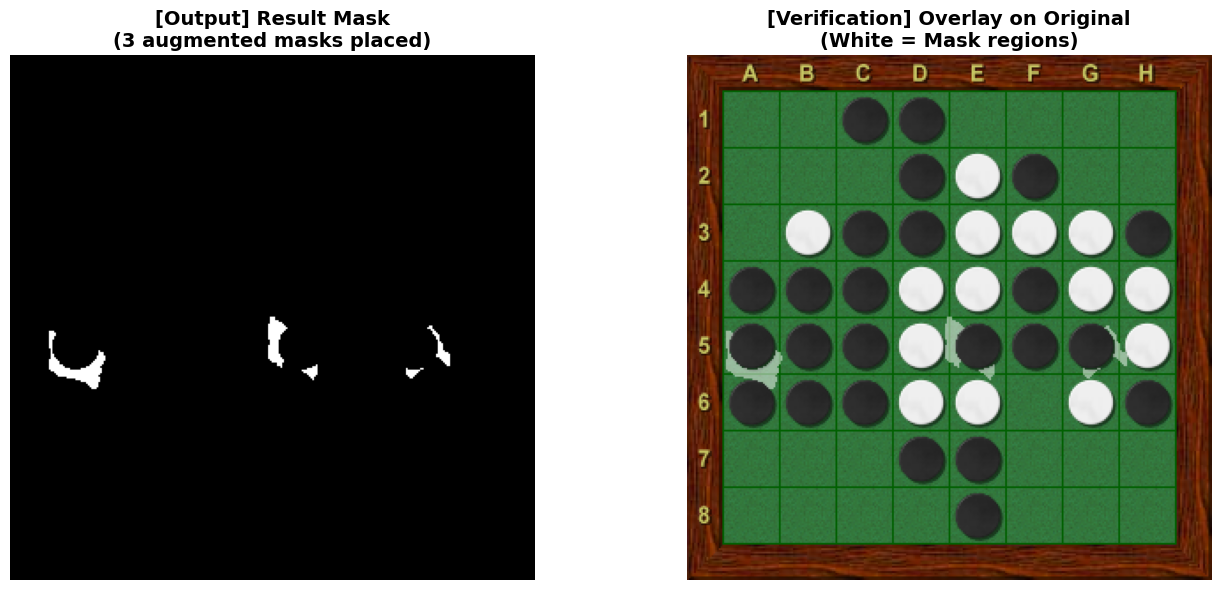

Main result generated successfully!


In [11]:
# Visualize output structure and main result
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

output_dir = 'results/automatic_mask_placement/reversi_example/seed_0001'

# Check directory structure
print("Output Directory Structure:")
print(f"{output_dir}/")
for root, dirs, files in os.walk(output_dir):
    level = root.replace(output_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}├── {os.path.basename(root)}/')
    subindent = '  ' * (level + 1)
    for file in sorted(files)[:5]:  # Show first 5 files
        print(f'{subindent}├── {file}')
    if len(files) > 5:
        print(f'{subindent}└── ... ({len(files)-5} more files)')

print("\n" + "="*60)

# Load and display main result
result_mask_path = os.path.join(output_dir, 'auto_placed_mask_with_3_rois_seed_1.png')
original_img_path = 'assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/reversi.png'

if os.path.exists(result_mask_path):
    result_mask = Image.open(result_mask_path)
    original_img = Image.open(original_img_path)
    
    # Create overlay
    overlay = original_img.copy().convert('RGBA')
    mask_overlay = result_mask.convert('RGBA')
    white_overlay = Image.new('RGBA', mask_overlay.size, (255, 255, 255, 0))
    for y in range(mask_overlay.height):
        for x in range(mask_overlay.width):
            if mask_overlay.getpixel((x, y))[0] > 127:  # White pixel in mask
                white_overlay.putpixel((x, y), (255, 255, 255, 128))  # 50% transparency
    overlay = Image.alpha_composite(overlay, white_overlay)
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(result_mask, cmap='gray')
    axes[0].set_title('[Output] Result Mask\n(3 augmented masks placed)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(overlay)
    axes[1].set_title('[Verification] Overlay on Original\n(White = Mask regions)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("Main result generated successfully!")
else:
    print(f"Result not found at: {result_mask_path}")


#### 2.5.4 Visualize Intermediate Products: Augmented Masks

Let's see the individual augmented masks before they were placed:


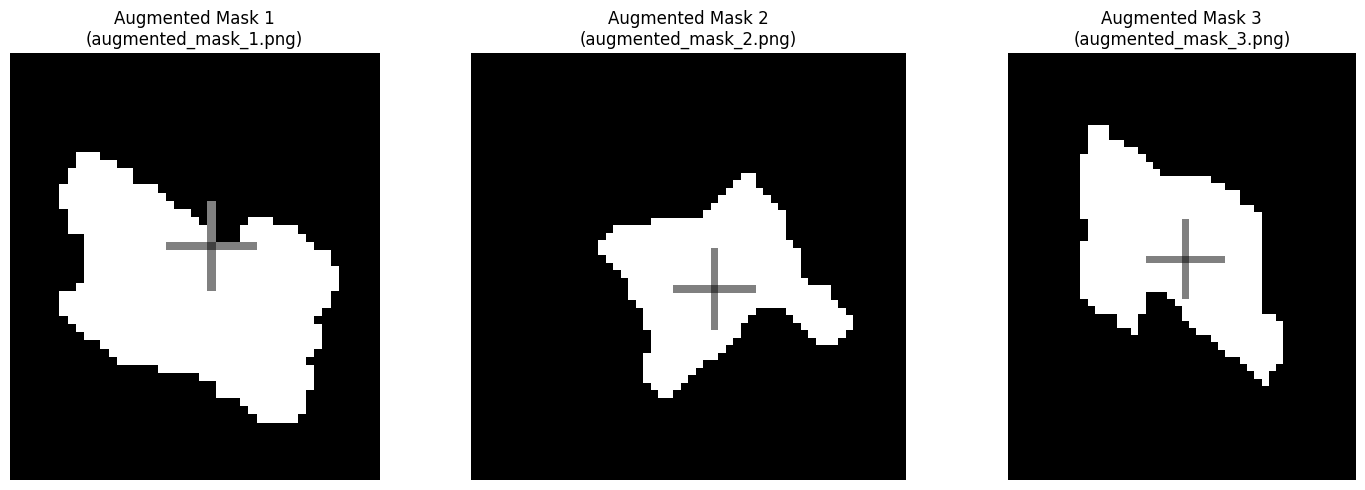

Found 3 augmented masks
Each mask was independently augmented (rotated, scaled, etc.) before placement

Note: In this example, no specific alignment is used, so masks are placed freely within ROIs. You can see that the mask alignment points, gray cross (+) are not point to the same submask location.
 For precise alignment control, see Example 2: Wood Crack Alignment below.


In [12]:
# Display augmented masks
aug_masks_dir = os.path.join(output_dir, 'augmented_masks')

if os.path.exists(aug_masks_dir):
    aug_files = sorted([f for f in os.listdir(aug_masks_dir) if f.endswith('.png')])
    
    if len(aug_files) > 0:
        fig, axes = plt.subplots(1, min(3, len(aug_files)), figsize=(15, 5))
        if len(aug_files) == 1:
            axes = [axes]
        
        for idx, aug_file in enumerate(aug_files[:3]):
            aug_img = Image.open(os.path.join(aug_masks_dir, aug_file))
            axes[idx].imshow(aug_img, cmap='gray')
            axes[idx].set_title(f'Augmented Mask {idx+1}\n({aug_file})', fontsize=12)
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Found {len(aug_files)} augmented masks")
        print("Each mask was independently augmented (rotated, scaled, etc.) before placement")
        print("\nNote: In this example, no specific alignment is used, so masks are placed freely within ROIs. You can see that the mask alignment points, gray cross (+) are not point to the same submask location.")
        print(" For precise alignment control, see Example 2: Wood Crack Alignment below.")
    else:
        print("No augmented masks found")
else:
    print(f"Directory not found: {aug_masks_dir}")


### 2.6 Example 2: Wood Crack Alignment

**Scenario:** Place crack masks along wood seams, ensuring cracks **attach to the seam edges**.

This example demonstrates **alignment control** - a critical feature for defects that must connect to specific features (edges, corners, etc.).

### 2.6.1 Step 1: Understand the Alignment Requirement

Wood cracks naturally follow seams. To achieve realistic placement:
1. Define ROIs **along the seam edges**
2. Use **`--roi_alignment_point`** to specify where in the ROI the mask should be placed (e.g., `top_center` of the ROI = seam edge)
3. Use **`--submask_alignment_point`** to specify which part of the crack aligns to that point (e.g., `top_left` = crack's starting point)
4. Use **`--strict_alignment`** to disable shifting and limit flipping, ensuring precise attachment

Let's visualize this:


INPUTS FOR THIS EXAMPLE:
[Input 1] Submask:      assets/anomaly_gen/auto_mask_placement_example_materials/wood_example/submask/wood_crack_submask.png
[Input 2] Legal ROI:    assets/anomaly_gen/auto_mask_placement_example_materials/wood_example/rois/image/legal/legal_rois_binary.png (Binary PNG file)

Input Method: Binary Image ROI (vs. JSON in Example 1)
 - White regions in the binary image define Legal ROIs
 - The tool will automatically separate connected regions into individual ROIs
 - See '6.2.4 Inspect Separated ROI Masks' section below to verify separation results



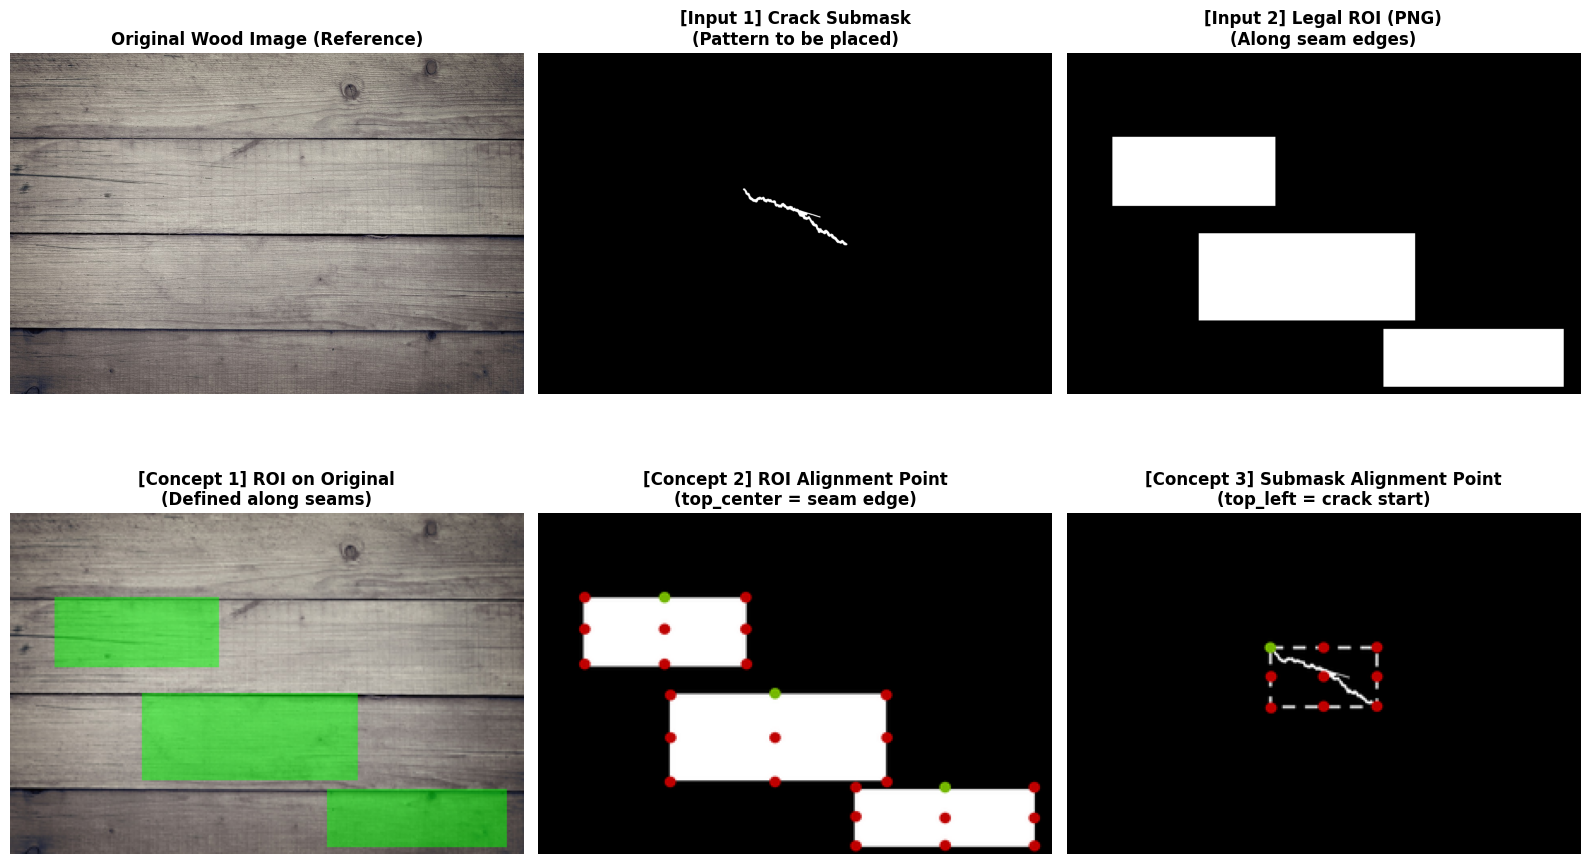


Key Alignment Concept:
 - ROIs are defined along seam edges (top_center of each ROI = the seam)
 - Submask's top_left (crack starting point) will align to ROI's top_center
 - This ensures cracks always attach to seams even after augmentations
 - --strict_alignment ensures no shifting, maintaining precise attachment


In [13]:
# Define paths (these are the ACTUAL inputs we'll use)
wood_dir = 'assets/anomaly_gen/auto_mask_placement_example_materials/wood_example'
wood_submask_path = os.path.join(wood_dir, 'submask/wood_crack_submask.png')
wood_roi_image_path = os.path.join(wood_dir, 'rois/image/legal/legal_rois_binary.png')
wood_original_path = os.path.join(wood_dir, 'image/wood-1794340_1280.jpg')

print("=" * 60)
print("INPUTS FOR THIS EXAMPLE:")
print("=" * 60)
print(f"[Input 1] Submask:      {wood_submask_path}")
print(f"[Input 2] Legal ROI:    {wood_roi_image_path} (Binary PNG file)")
print("=" * 60)
print("\nInput Method: Binary Image ROI (vs. JSON in Example 1)")
print(" - White regions in the binary image define Legal ROIs")
print(" - The tool will automatically separate connected regions into individual ROIs")
print(" - See '6.2.4 Inspect Separated ROI Masks' section below to verify separation results\n")

# Load actual inputs
wood_submask = Image.open(wood_submask_path)
wood_roi_image = Image.open(wood_roi_image_path)
wood_original = Image.open(wood_original_path)

# Visualize inputs and alignment concept
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Inputs
axes[0, 0].imshow(wood_original)
axes[0, 0].set_title('Original Wood Image (Reference)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(wood_submask, cmap='gray')
axes[0, 1].set_title('[Input 1] Crack Submask\n(Pattern to be placed)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(wood_roi_image, cmap='gray')
axes[0, 2].set_title('[Input 2] Legal ROI (PNG)\n(Along seam edges)', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Alignment visualization
roi_overlay = Image.open(os.path.join(wood_dir, 'alignment_template_figures/wood_roi_overlay.png'))
roi_alignment = Image.open(os.path.join(wood_dir, 'alignment_template_figures/wood_roi_alignment_points.png'))
submask_alignment = Image.open(os.path.join(wood_dir, 'alignment_template_figures/wood_submask_alignment_points.png'))

axes[1, 0].imshow(roi_overlay)
axes[1, 0].set_title('[Concept 1] ROI on Original\n(Defined along seams)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(roi_alignment)
axes[1, 1].set_title('[Concept 2] ROI Alignment Point\n(top_center = seam edge)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(submask_alignment)
axes[1, 2].set_title('[Concept 3] Submask Alignment Point\n(top_left = crack start)', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\nKey Alignment Concept:")
print(" - ROIs are defined along seam edges (top_center of each ROI = the seam)")
print(" - Submask's top_left (crack starting point) will align to ROI's top_center")
print(" - This ensures cracks always attach to seams even after augmentations")
print(" - --strict_alignment ensures no shifting, maintaining precise attachment")


#### 2.6.2 Step 2: Run with Alignment Parameters


In [ ]:
!conda run -n cosmos-predict2 \
    bash -c "python3 -m scripts.anomaly_gen.automatic_mask_placement \
        --submask assets/anomaly_gen/auto_mask_placement_example_materials/wood_example/submask/wood_crack_submask.png \
        --roi_image assets/anomaly_gen/auto_mask_placement_example_materials/wood_example/rois/image/legal/legal_rois_binary.png \
        --n 3 \
        --output_base_dir results/automatic_mask_placement/wood_alignment \
        --seed 42 \
        --roi_alignment_point top_center \
        --submask_alignment_point top_left \
        --strict_alignment \
        --save_cropped_submask \
        --save_augmented_masks \
        --save_separated_rois \
        --save_visualize"


#### 2.6.3 Step 3: Visualize Results

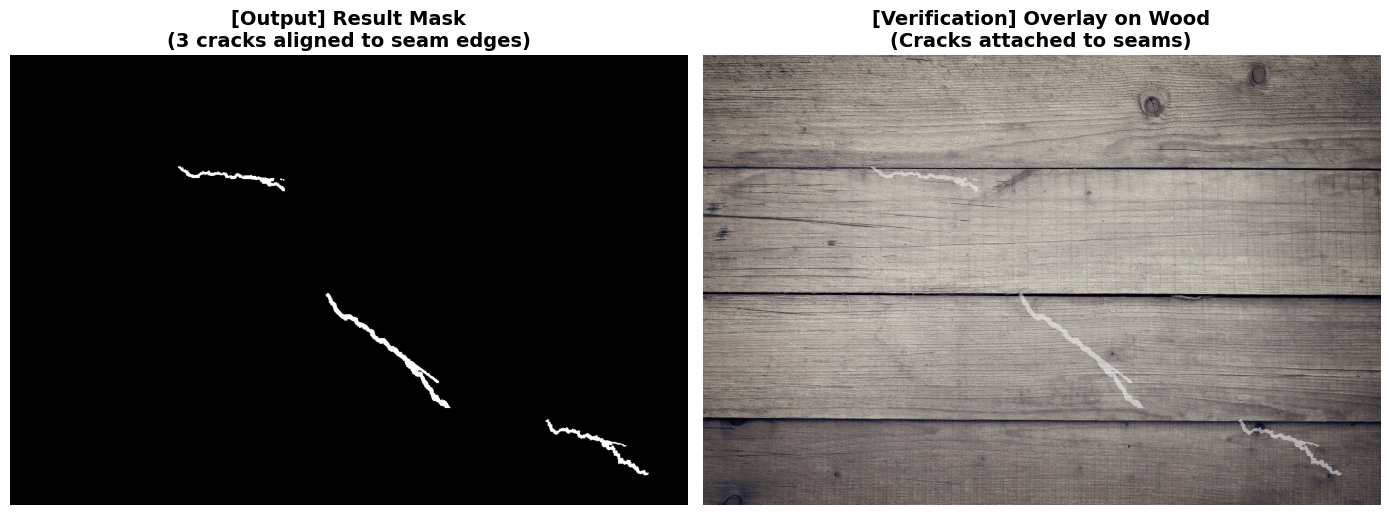

Wood crack alignment successful!
Notice: All cracks start from the seam edges, even though they're rotated/scaled differently
This is achieved by --roi_alignment_point top_center --submask_alignment_point top_left and --strict_alignment

The alignment point ensures cracks attach to seams regardless of augmentation!


In [15]:
# Visualize wood crack alignment results
wood_output_dir = 'results/automatic_mask_placement/wood_alignment/seed_0042'
wood_original = 'assets/anomaly_gen/auto_mask_placement_example_materials/wood_example/image/wood-1794340_1280.jpg'

# Load result and overlay
result_files = [f for f in os.listdir(wood_output_dir) if f.startswith("auto_placed_mask")] if os.path.exists(wood_output_dir) else []

if result_files:
    result_mask = Image.open(os.path.join(wood_output_dir, result_files[0]))
    original_wood = Image.open(wood_original)
    
    # Create overlay
    overlay = original_wood.copy().convert('RGBA')
    mask_overlay = result_mask.convert('RGBA')
    white_overlay = Image.new('RGBA', mask_overlay.size, (255, 255, 255, 0))
    for y in range(mask_overlay.height):
        for x in range(mask_overlay.width):
            if mask_overlay.getpixel((x, y))[0] > 127:
                white_overlay.putpixel((x, y), (255, 255, 255, 128))
    overlay = Image.alpha_composite(overlay, white_overlay)
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(result_mask, cmap='gray')
    axes[0].set_title('[Output] Result Mask\n(3 cracks aligned to seam edges)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(overlay)
    axes[1].set_title('[Verification] Overlay on Wood\n(Cracks attached to seams)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("Wood crack alignment successful!")
    print("Notice: All cracks start from the seam edges, even though they're rotated/scaled differently")
    print("This is achieved by --roi_alignment_point top_center --submask_alignment_point top_left and --strict_alignment")
    print("\nThe alignment point ensures cracks attach to seams regardless of augmentation!")
else:
    print(f"Result not found. Please run the command above first.")


#### 2.6.4 Visualize Intermediate Products: Augmented Masks (and Alignment Points)

Let's examine the intermediate augmented masks. **Look for the gray cross (+) marker** in each mask - this marks the alignment point that stays fixed during augmentation:


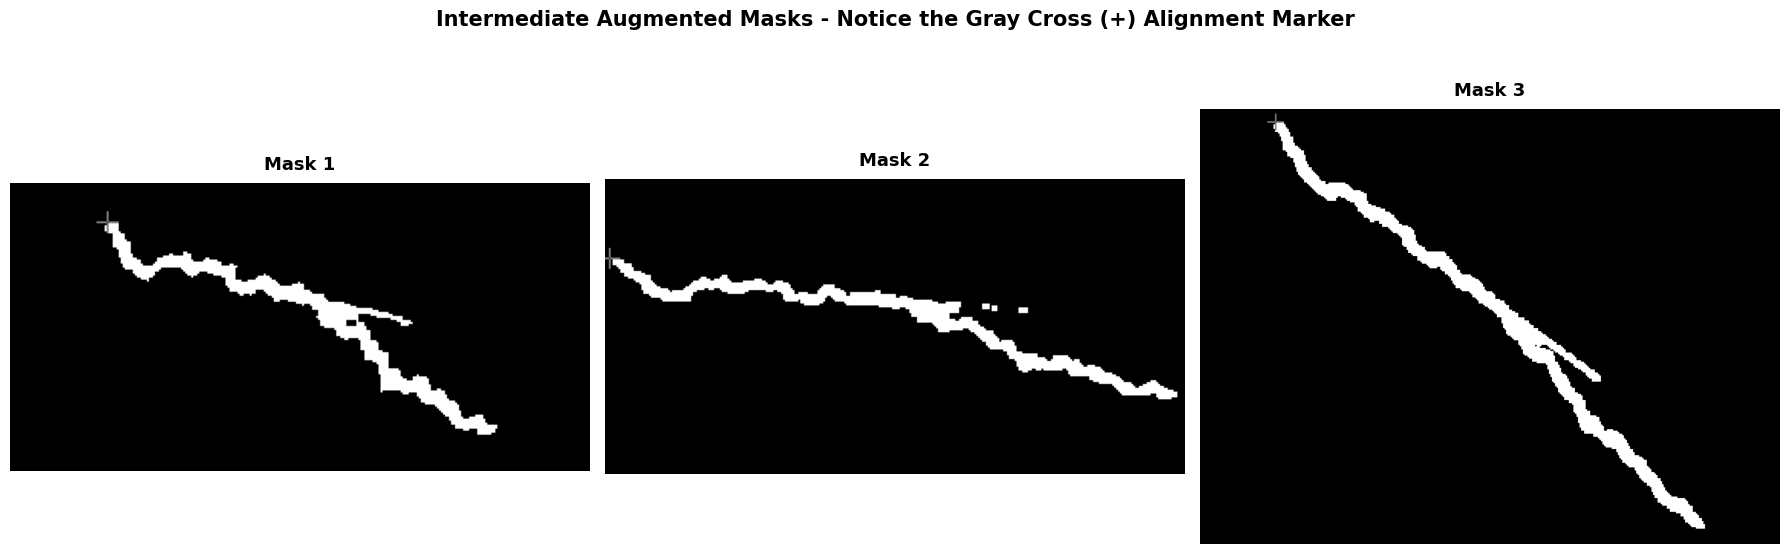

Found 3 augmented masks

Key Observation - Alignment Point Marker:
Look at the gray cross (+) in the top-left corner of each mask!
This cross marks the submask_alignment_point (top_left)
Notice: The cross stays at the crack's starting point even after rotation/scaling
This ensures the crack's start always aligns to the ROI's top_center (seam edge)
Alignment happens BEFORE placement, guaranteeing precise attachment

Each mask underwent different augmentations (rotation, scale, shear)
but the alignment point remains fixed, ensuring correct placement!


In [16]:
# Check if augmented masks directory exists
augmented_dir = f"{wood_output_dir}/augmented_masks"

if os.path.exists(augmented_dir):
    augmented_files = sorted([f for f in os.listdir(augmented_dir) if f.endswith('.png')])
    
    if augmented_files:
        # Display augmented masks in a horizontal layout for better space utilization
        n_masks = len(augmented_files)
        
        # Create figure with horizontal layout
        fig, axes = plt.subplots(1, n_masks, figsize=(18, 6))
        if n_masks == 1:
            axes = [axes]
        
        fig.suptitle('Intermediate Augmented Masks - Notice the Gray Cross (+) Alignment Marker', 
                     fontsize=15, fontweight='bold', y=0.98)
        
        for idx, filename in enumerate(augmented_files):
            aug_mask = Image.open(os.path.join(augmented_dir, filename))
            axes[idx].imshow(aug_mask, cmap='gray')
            axes[idx].set_title(f'Mask {idx+1}', fontsize=13, fontweight='bold', pad=10)
            axes[idx].axis('off')
            
            # Add a border around each subplot for clarity
            for spine in axes[idx].spines.values():
                spine.set_edgecolor('lightgray')
                spine.set_linewidth(2)
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        print(f"Found {len(augmented_files)} augmented masks\n")
        print("Key Observation - Alignment Point Marker:")
        print("Look at the gray cross (+) in the top-left corner of each mask!")
        print("This cross marks the submask_alignment_point (top_left)")
        print("Notice: The cross stays at the crack's starting point even after rotation/scaling")
        print("This ensures the crack's start always aligns to the ROI's top_center (seam edge)")
        print("Alignment happens BEFORE placement, guaranteeing precise attachment\n")
        print("Each mask underwent different augmentations (rotation, scale, shear)")
        print("but the alignment point remains fixed, ensuring correct placement!")
    else:
        print(f"No augmented masks found in {augmented_dir}")
else:
    print(f"Augmented masks directory not found: {augmented_dir}")
    print("Tip: Run the command with --save_augmented_masks to save intermediate results")


#### 2.6.5 Visualize Intermediate Products: Separated ROIs

**Verification of Binary Image ROI Separation:**

When using a binary PNG image for Legal ROIs, the tool automatically separates connected white regions into individual ROIs using a roi separator. Let's verify this separation:


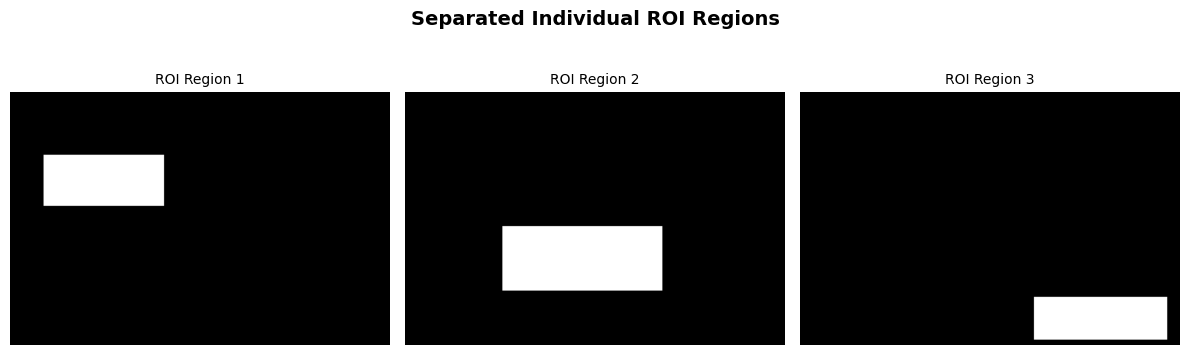

Found 3 separated ROI regions
Each region is a potential placement location for the submask


In [17]:
# Check if separated ROI masks directory exists
separated_roi_dir = f"{wood_output_dir}/separated_roi_masks"

if os.path.exists(separated_roi_dir):
    separated_files = sorted([f for f in os.listdir(separated_roi_dir) if f.endswith('.png')])
    
    if separated_files:
        # Display all separated ROI masks
        n_rois = len(separated_files)
        cols = 3
        rows = (n_rois + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
        fig.suptitle('Separated Individual ROI Regions', fontsize=14, fontweight='bold')
        
        if rows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()
        
        for idx, filename in enumerate(separated_files):
            sep_roi = Image.open(os.path.join(separated_roi_dir, filename))
            axes[idx].imshow(sep_roi, cmap='gray')
            axes[idx].set_title(f'ROI Region {idx+1}', fontsize=10)
            axes[idx].axis('off')
        
        # Hide unused subplots
        for idx in range(n_rois, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Found {n_rois} separated ROI regions")
        print(f"Each region is a potential placement location for the submask")
    else:
        print(f"No separated ROI masks found in {separated_roi_dir}")
else:
    print(f"Separated ROI masks directory not found: {separated_roi_dir}")
    print("Tip: Run the command with --save_separated_rois to save individual ROI regions")


### 2.7 Batch Generation with Seed Range

Batch generation allow users to generate auto-placed masks results from a range of seed

In [ ]:
# Parallel batch generation (faster for large datasets)
!conda run -n cosmos-predict2 \
    bash -c "python3 -m scripts.anomaly_gen.automatic_mask_placement \
        --rois assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/rois/json/reversi_sample_rois.json \
        --illegal_roi_image assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/rois/image/illegal/reversi_sample_illegal_region.png \
        --submask assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/submask/reversi_sample_submask.png \
        --output_base_dir results/automatic_mask_placement/reversi_batch_parallel \
        --n 3 \
        --seed_range 1 50 \
        --parallel_workers 4 \
        --save_visualize \
        --save_separated_rois \
        --save_augmented_masks"


#### 2.7.1 Batch Results Comparison

After batch generation, let's compare the results from different seeds to see the diversity:


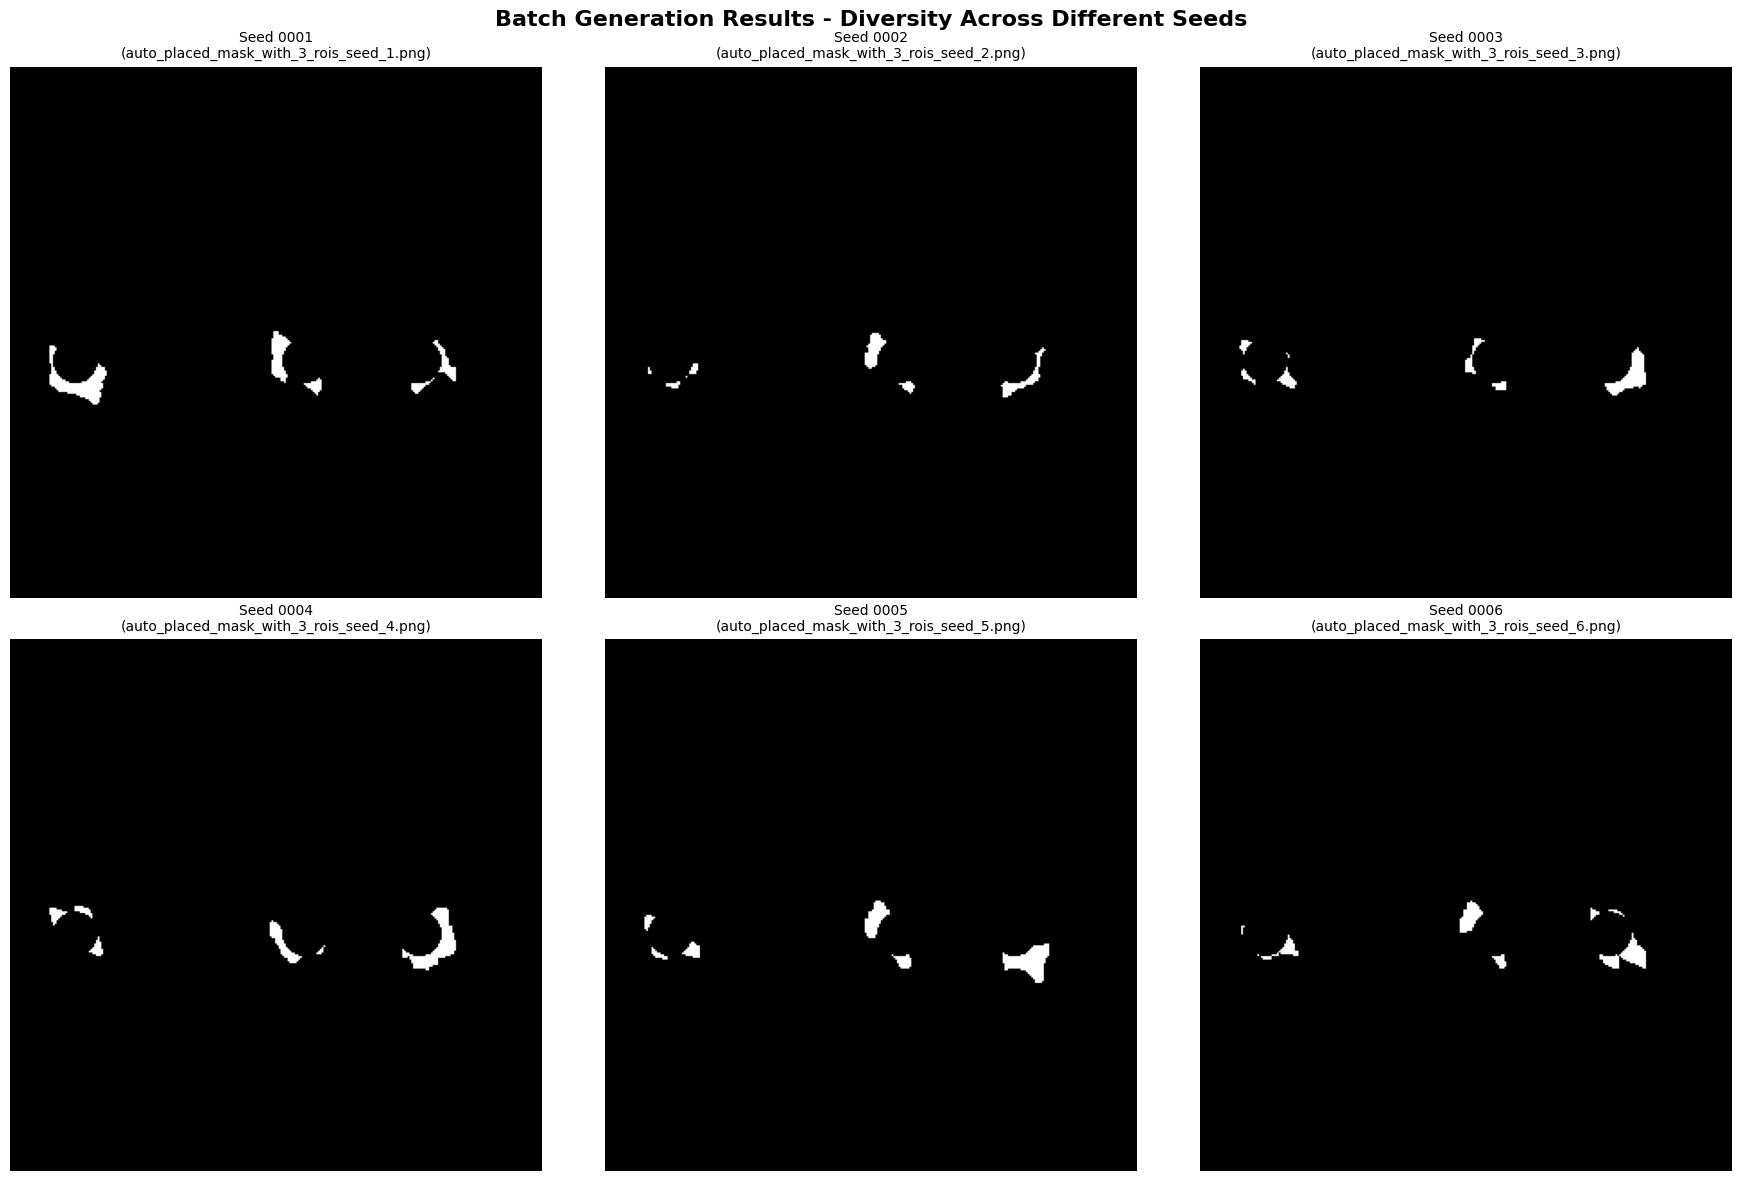

Batch generation complete: 50 seeds generated
Output directory: results/automatic_mask_placement/reversi_batch_parallel
Each seed produces different augmentations and placements
Use these diverse masks for training robust anomaly detection models


In [19]:
# Batch output directory from the example above
batch_output_dir = "results/automatic_mask_placement/reversi_batch_parallel"

# Check if batch directory exists
if os.path.exists(batch_output_dir):
    # Get all seed directories
    seed_dirs = sorted([d for d in os.listdir(batch_output_dir) if d.startswith('seed_')])
    
    if seed_dirs:
        # Display up to 6 different seed results
        n_samples = min(len(seed_dirs), 6)
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Batch Generation Results - Diversity Across Different Seeds', fontsize=16, fontweight='bold')
        
        axes = axes.flatten()
        for idx, seed_dir in enumerate(seed_dirs[:n_samples]):
            seed_path = os.path.join(batch_output_dir, seed_dir)
            result_files = [f for f in os.listdir(seed_path) if f.startswith("auto_placed_mask")]
            
            if result_files:
                result_img = Image.open(os.path.join(seed_path, result_files[0]))
                axes[idx].imshow(result_img, cmap='gray')
                
                # Extract seed number from filename or directory name
                seed_num = seed_dir.replace('seed_', '')
                axes[idx].set_title(f'Seed {seed_num}\n({result_files[0]})', fontsize=10)
                axes[idx].axis('off')
        
        # Hide unused subplots
        for idx in range(n_samples, 6):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Batch generation complete: {len(seed_dirs)} seeds generated")
        print(f"Output directory: {batch_output_dir}")
        print(f"Each seed produces different augmentations and placements")
        print(f"Use these diverse masks for training robust anomaly detection models")
    else:
        print(f"No seed directories found in {batch_output_dir}")
else:
    print(f"Batch output directory not found: {batch_output_dir}")
    print("Tip: Run the batch generation command above first")


#### 2.7.2 Batch Generation Statistics

Let's analyze the batch generation output to understand the dataset characteristics:


In [20]:
import glob

if os.path.exists(batch_output_dir):
    seed_dirs = sorted([d for d in os.listdir(batch_output_dir) if d.startswith('seed_')])
    
    if seed_dirs:
        print("=" * 60)
        print("BATCH GENERATION STATISTICS")
        print("=" * 60)
        print(f"\nTotal Seeds Generated: {len(seed_dirs)}")
        
        # Count files per seed
        total_masks = 0
        total_augmented = 0
        total_separated_rois = 0
        
        for seed_dir in seed_dirs:
            seed_path = os.path.join(batch_output_dir, seed_dir)
            
            # Count main result masks
            result_files = [f for f in os.listdir(seed_path) if f.startswith("auto_placed_mask") and f.endswith('.png')]
            total_masks += len(result_files)
            
            # Count augmented masks if directory exists
            aug_dir = os.path.join(seed_path, "augmented_masks")
            if os.path.exists(aug_dir):
                aug_files = [f for f in os.listdir(aug_dir) if f.endswith('.png')]
                total_augmented += len(aug_files)
            
            # Count separated ROI masks if directory exists
            sep_roi_dir = os.path.join(seed_path, "separated_roi_masks")
            if os.path.exists(sep_roi_dir):
                sep_files = [f for f in os.listdir(sep_roi_dir) if f.endswith('.png')]
                total_separated_rois = len(sep_files)  # Same for all seeds
        
        print(f"Total Result Masks: {total_masks}")
        if total_augmented > 0:
            print(f"Total Augmented Masks: {total_augmented}")
        if total_separated_rois > 0:
            print(f"Separated ROI Regions: {total_separated_rois} (per seed)")
        
        # Show sample output structure
        print(f"\nOutput Directory Structure:")
        print(f"   {batch_output_dir}/")
        for i, seed_dir in enumerate(seed_dirs[:3]):
            print(f"   ├── {seed_dir}/")
            seed_path = os.path.join(batch_output_dir, seed_dir)
            files = os.listdir(seed_path)
            for f in sorted(files)[:3]:
                print(f"   │   ├── {f}")
            if len(files) > 3:
                print(f"   │   └── ... ({len(files)-3} more items)")
        
        if len(seed_dirs) > 3:
            print(f"   └── ... ({len(seed_dirs)-3} more seed directories)")
        
        print("\n" + "=" * 60)
        print("Batch generation summary complete")
        print("=" * 60)
    else:
        print("No seed directories found")
else:
    print(f"Directory not found: {batch_output_dir}")


BATCH GENERATION STATISTICS

Total Seeds Generated: 50
Total Result Masks: 50
Total Augmented Masks: 150
Separated ROI Regions: 3 (per seed)

Output Directory Structure:
   results/automatic_mask_placement/reversi_batch_parallel/
   ├── seed_0001/
   │   ├── augmented_masks
   │   ├── auto_placed_mask_with_3_rois_seed_1.png
   │   ├── roi_visualization.png
   │   └── ... (1 more items)
   ├── seed_0002/
   │   ├── augmented_masks
   │   ├── auto_placed_mask_with_3_rois_seed_2.png
   │   ├── roi_visualization.png
   │   └── ... (1 more items)
   ├── seed_0003/
   │   ├── augmented_masks
   │   ├── auto_placed_mask_with_3_rois_seed_3.png
   │   ├── roi_visualization.png
   │   └── ... (1 more items)
   └── ... (47 more seed directories)

Batch generation summary complete


### 2.8 Output Structure

The automatic mask placement generates organized outputs for easy inspection and downstream use.

#### 2.8.1 Single Seed Output

When running with a single seed (e.g., `--seed 42`), the output structure is:

```
output_base_dir/
└── seed_0042/                                    # Seed subdirectory
    ├── auto_placed_mask_with_N_rois_seed_42.png # Main result with N instances
    ├── cropped_submask.png                       # Cropped submask (if --save_cropped_submask)
    ├── roi_visualization.png                     # ROI overlay (if --save_visualize)
    ├── roi_binaries/                             # ROI binary images (if --save_roi_binaries)
    │   ├── legal_rois_binary.png
    │   ├── illegal_rois_binary.png
    │   └── combined_rois_binary.png
    ├── separated_roi_masks/                      # Individual ROI masks (if --save_separated_rois)
    │   ├── separated_roi_001.png
    │   ├── separated_roi_002.png
    │   └── ...
    └── augmented_masks/                          # Intermediate augmented masks (if --save_augmented_masks)
        ├── augmented_mask_1.png
        ├── augmented_mask_2.png
        └── ...
```

**Key Files:**
- **Main Result**: `auto_placed_mask_with_N_rois_seed_X.png` - Final combined mask with all instances
- **Augmented Masks**: Individual masks after augmentation but before placement (useful for debugging alignment)
- **Separated ROIs**: Individual ROI regions extracted from the input (useful for verifying binary image ROI separation)

#### 2.8.2 Batch Processing Output

When running batch mode (e.g., `--seed_range 1 50`), each seed creates its own subdirectory:

```
output_base_dir/
├── seed_0001/
│   ├── auto_placed_mask_with_N_rois_seed_1.png
│   ├── augmented_masks/
│   │   ├── augmented_mask_1.png
│   │   ├── augmented_mask_2.png
│   │   └── ...
│   └── ...
├── seed_0002/
│   ├── auto_placed_mask_with_3_rois_seed_2.png
│   └── ...
├── seed_0003/
│   └── ...
└── seed_0050/
    └── ...
```

Each seed directory contains the complete output set, enabling easy comparison and selection of the best results for your specific use case.


### 2.9 Prepare Generation Configuration for Anomaly Generation Inference

After batch generation with automatic mask placement, now we can generate a sample `.jsonl` testcase file for anomaly generation inference using `create_testcase.py`. The JSONL file contains the input configurations for anomaly generation inference (see [3-generation.ipynb](./3-generation.ipynb) for detailed file format).

#### Why No Additional Augmentation is Needed

The automatic mask placement tool **already applies intelligent augmentation** during mask generation:
- **Random transformations**: rotation, scaling, shifting, flipping
- **Morphological operations**: dilation, erosion, opening, closing
- **ROI-aware constraints**: ensures masks stay within legal boundaries
- **Alignment preservation**: maintains precise positioning for structured defects


---

#### 2.9.1 Organize Generated (Auto Placed) Masks into Required Structure

**Required structure for `create_testcase.py` as mentioned in README:** 
```
<dataset_dir>/
  └── <TEXTURE>/
      └── mask/
          └── <anomaly_type>/
              ├── mask_1.png
              ├── mask_2.png
              └── ...
```

Let's reorganize our batch-generated masks:


In [21]:
import os
import shutil
from pathlib import Path

# Define paths
batch_output_dir = "results/automatic_mask_placement/reversi_batch_parallel"
organized_mask_dir = "results/automatic_mask_placement/reversi_batch_organized"

# Create organized structure
texture_name = "reversi"
anomaly_type = "auto_placed_defects"
target_dir = os.path.join(organized_mask_dir, texture_name, "mask", anomaly_type)
os.makedirs(target_dir, exist_ok=True)

# Copy masks from batch output to organized structure
if os.path.exists(batch_output_dir):
    seed_dirs = sorted([d for d in os.listdir(batch_output_dir) if d.startswith('seed_')])
    
    copied_count = 0
    for seed_dir in seed_dirs:
        # Extract seed number without leading zeros (e.g., seed_0001 -> 1)
        seed_num = int(seed_dir.replace('seed_', ''))
        
        # Find the main result mask (filename uses seed number without leading zeros)
        mask_path = os.path.join(batch_output_dir, seed_dir, f"auto_placed_mask_with_3_rois_seed_{seed_num}.png")
        
        if os.path.exists(mask_path):
            # Copy with a simpler name (also without leading zeros)
            target_name = f"auto_placed_mask_seed_{seed_num}.png"
            target_path = os.path.join(target_dir, target_name)
            shutil.copy2(mask_path, target_path)
            copied_count += 1
        else:
            print(f"⚠️  Mask not found: {mask_path}")
    
    print(f"Organized {copied_count} masks into structure:")
    print(f"   {target_dir}")
    print(f"\nDirectory structure:")
    print(f"   {organized_mask_dir}/")
    print(f"   └── {texture_name}/")
    print(f"       └── mask/")
    print(f"           └── {anomaly_type}/")
    print(f"               ├── auto_placed_mask_seed_1.png")
    print(f"               ├── auto_placed_mask_seed_2.png")
    print(f"               └── ... ({copied_count} masks total)")
else:
    print(f"Batch output directory not found: {batch_output_dir}")


Organized 50 masks into structure:
   results/automatic_mask_placement/reversi_batch_organized/reversi/mask/auto_placed_defects

Directory structure:
   results/automatic_mask_placement/reversi_batch_organized/
   └── reversi/
       └── mask/
           └── auto_placed_defects/
               ├── auto_placed_mask_seed_1.png
               ├── auto_placed_mask_seed_2.png
               └── ... (50 masks total)


####  2.9.2 Generate JSONL Testcase File
- `--SDG_RATIO 1`: Since we're using pre-placed masks without augmentation, we only need 1 testcase per mask
- `--disable_augmentation`: Preserve the precise placement from automatic mask placement (shift=0, rotation=0, morph=none)
- `--clean_image_dir`: Directory containing the clean image (will be paired with all masks)
- `--dataset_dir`: Directory containing our organized masks

In [22]:
!conda run -n cosmos-predict2 \
    python3 -m scripts.anomaly_gen.create_testcase \
        --clean_image_dir assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/ \
        --dataset_dir results/automatic_mask_placement/reversi_batch_organized \
        --name reversi \
        --SDG_RATIO 1 \
        --disable_augmentation

[11-28 15:56:13|INFO|scripts/anomaly_gen/create_testcase.py:170:<module>] Output file: ag_inference/reversi/testcase_1x_guidance=1.5_crop_ratio=2.0_poisson_blend=False.jsonl



In [23]:
# Verify the generated testcase.jsonl file
!cat ag_inference/reversi/testcase_1x_guidance=1.5_crop_ratio=2.0_poisson_blend=False.jsonl

{"image_filename": "assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/reversi.png", "mask_filename": "results/automatic_mask_placement/reversi_batch_organized/reversi/mask/auto_placed_defects/auto_placed_mask_seed_38.png", "anomaly_type": "reversi+auto_placed_defects", "guidance": 1.5, "num_steps": 35, "crop_and_paste": true, "crop_ratio": 2.0, "crop_grid_X": 192, "crop_grid_Y": 192, "num_generated_images": 1, "poisson_blend": false, "shift_values": "0,0", "rotation_angle": 0, "morph_operation": "none", "iteration_generation_max_instance": 5}
{"image_filename": "assets/anomaly_gen/auto_mask_placement_example_materials/reversi_example/image/reversi.png", "mask_filename": "results/automatic_mask_placement/reversi_batch_organized/reversi/mask/auto_placed_defects/auto_placed_mask_seed_39.png", "anomaly_type": "reversi+auto_placed_defects", "guidance": 1.5, "num_steps": 35, "crop_and_paste": true, "crop_ratio": 2.0, "crop_grid_X": 192, "crop_grid_Y": 192, "num_g

## Next Step

You can now proceed to the next step to generate anomaly data with the provided masks: [3-generation.ipynb](./3-generation.ipynb)